In [50]:
import pandas as pd 
import re ,string
from tensorflow.keras.models  import Sequential 
from tensorflow.keras.layers import Embedding, Conv1D ,MaxPooling1D,Flatten,Dense,Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import plot_model
from sklearn.model_selection import train_test_split


from nltk.corpus import stopwords
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

## TABLE OF CONTENTS 

-  CNN EMBDDINGS MODEL
-  LOW **MAX LENGTH** SIZE % 
-  LOW **VOCAB SIZE** %

In [51]:
data =  pd.read_csv("./movie_review.csv")[["text","tag"]]
data["tag"] =  data["tag"].map({"pos":1,"neg":0})
data.head()

,text,tag
0,films adapted from comic books have had plenty...,1
1,"for starters , it was created by alan moore ( ...",1
2,to say moore and campbell thoroughly researche...,1
3,"the book ( or "" graphic novel , "" if you will ...",1
4,"in other words , don't dismiss this film becau...",1


In [52]:
STOPWORDS =  stopwords.words("english")

def removing_special_chars(text):
    pat = r'[^a-zA-z0-9.,!?/:;\"\'\s]'
    return re.sub(pat,' ',text)

def removing_numbers(text):
    pattern = r'[^a-zA-z.,!?/:;\"\'\s]' 
    return re.sub(pattern,' ',text)

def remove_punctuation(text):
    return ''.join([c for c in text if c not in string.punctuation])


def clean_text(text):
    text = text.lower()
    text = removing_numbers(text)
    text = remove_punctuation(text)
    text = " ".join(w for w in text.split() if w not in STOPWORDS)
    return text 

In [53]:
data["text_cleaned"]   = data["text"].apply(lambda x :  clean_text(x))
x_train,x_test,y_train,y_test =  train_test_split(data["text_cleaned"],data["tag"],test_size=0.2,stratify=data["tag"],random_state=42) 

In [54]:
print("Sample : ")
print("X_train shape : ",x_train.shape)
print("Y train shape : ",y_train.shape)
print(data.iloc[:5,:])

Sample : 
X_train shape :  (51776,)
Y train shape :  (51776,)
                                                text  tag  \
0  films adapted from comic books have had plenty...    1   
1  for starters , it was created by alan moore ( ...    1   
2  to say moore and campbell thoroughly researche...    1   
3  the book ( or " graphic novel , " if you will ...    1   
4  in other words , don't dismiss this film becau...    1   

                                        text_cleaned  
0  films adapted comic books plenty success wheth...  
1  starters created alan moore eddie campbell bro...  
2  say moore campbell thoroughly researched subje...  
3  book graphic novel pages long includes nearly ...  
4                     words dont dismiss film source  


In [55]:
max_length =  50
embed_dim=16

In [56]:
token =  Tokenizer()
token.fit_on_texts(x_train)


x_train_ =  token.texts_to_sequences(x_train)
x_train_pad =  pad_sequences(x_train_,maxlen=max_length,padding="post")


x_test_ =  token.texts_to_sequences(x_test)
x_test_pad =  pad_sequences(x_test_,maxlen=max_length,padding="post")


#### Average length of the training length 
=> set it to 95th percentile 

In [57]:
vocab_size =  len(token.word_index) +1 
print("Vocab size : ",vocab_size)

lengths = [len(x.split()) for x in data['text']]
print("Avg length :",np.mean(lengths), "95th percentile: ",np.percentile(lengths, 95))

Vocab size :  37975
Avg length : 23.063674289245984 95th percentile:  48.0


#### If I use low max length , how much imp data is lost ??  
#### => the code just results in this 

| Truncated %  | Meaning                                         |
| ------------ | ----------------------------------------------- |
| **< 5%**     | ✅ 50 tokens is safe                             |
| **5–15%**    | ⚠️ Mild truncation, maybe increase to 60        |
| **> 15–20%** | ❌ Too short — increase `maxlen` closer to 80–83 |


🔹 Train sequences truncated: 0.09%
🔹 Test sequences truncated : 0.06%


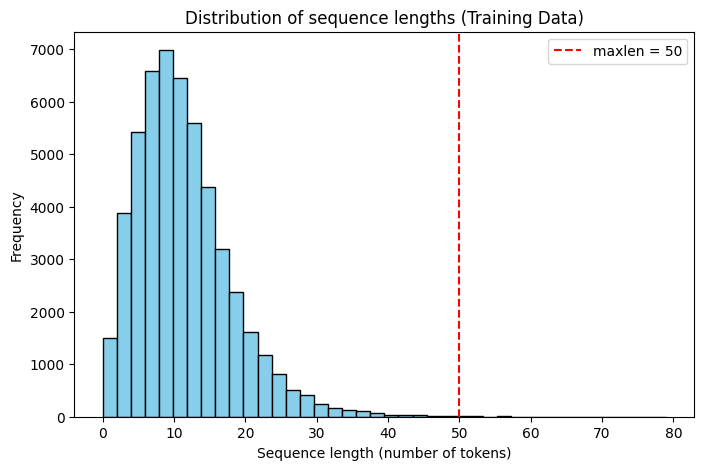

In [58]:


# Compute actual sequence lengths before padding/truncation
train_lengths = [len(seq) for seq in x_train_]
test_lengths  = [len(seq) for seq in x_test_]

# Calculate truncation percentage
train_truncated = np.sum(np.array(train_lengths) > max_length) / len(train_lengths) * 100
test_truncated  = np.sum(np.array(test_lengths) > max_length) / len(test_lengths) * 100

print(f"🔹 Train sequences truncated: {train_truncated:.2f}%")
print(f"🔹 Test sequences truncated : {test_truncated:.2f}%")

# Optional: visualize token length distribution
plt.figure(figsize=(8,5))
plt.hist(train_lengths, bins=40, color='skyblue', edgecolor='black')
plt.axvline(max_length, color='red', linestyle='--', label=f"maxlen = {max_length}")
plt.xlabel("Sequence length (number of tokens)")
plt.ylabel("Frequency")
plt.title("Distribution of sequence lengths (Training Data)")
plt.legend()
plt.show()


### If i use low vocab size How much imp data will get lost 

**Interpretation**:

=> If OOV < 1–2%, your vocab is sufficient. <br />
=> If OOV > 5–10%, your model will lose a lot of information, as many rare words will be mapped to


In [59]:

# Flatten all words in training data
all_words = [word for seq in x_train_ for word in seq]
word_counts = Counter(all_words)


# Count words outside the vocab
total_words = len(all_words)
oov_words = sum(count for word, count in word_counts.most_common()[vocab_size:])
oov_percentage = (oov_words / total_words) * 100

print(f"Total words: {total_words}")
print(f"OOV words: {oov_words} ({oov_percentage:.2f}%)")


Total words: 572300
OOV words: 0 (0.00%)


**Accuracy might be low but you got the working !!**

In [60]:
model =  Sequential([
    Embedding(vocab_size,embed_dim,input_length=max_length),
    Conv1D(filters=32,kernel_size=8,activation="relu"),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    Flatten(),
    Dense(10,activation="relu"),
    Dropout(0.3),
    Dense(1,activation="sigmoid")
])
model.compile(loss="binary_crossentropy",optimizer="adam",metrics=["acc"])
model.summary()


Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_6 (Embedding)     (None, 50, 16)            607600    
                                                                 
 conv1d_6 (Conv1D)           (None, 43, 32)            4128      
                                                                 
 max_pooling1d_6 (MaxPoolin  (None, 21, 32)            0         
 g1D)                                                            
                                                                 
 dropout_4 (Dropout)         (None, 21, 32)            0         
                                                                 
 flatten_6 (Flatten)         (None, 672)               0         
                                                                 
 dense_12 (Dense)            (None, 10)                6730      
                                                      

In [61]:
history =  model.fit(x_train_pad,y_train,epochs=10,validation_data=(x_test_pad,y_test))

Epoch 1/10
1618/1618 [==============================] - 10s 6ms/step - loss: 0.6442 - acc: 0.6145 - val_loss: 0.5920 - val_acc: 0.6780
Epoch 2/10
1618/1618 [==============================] - 10s 6ms/step - loss: 0.4971 - acc: 0.7658 - val_loss: 0.5918 - val_acc: 0.6835
Epoch 3/10
1618/1618 [==============================] - 9s 6ms/step - loss: 0.3523 - acc: 0.8484 - val_loss: 0.6980 - val_acc: 0.6783
Epoch 4/10
1618/1618 [==============================] - 10s 6ms/step - loss: 0.2287 - acc: 0.9073 - val_loss: 0.8926 - val_acc: 0.6676
Epoch 5/10
1618/1618 [==============================] - 10s 6ms/step - loss: 0.1597 - acc: 0.9356 - val_loss: 1.1507 - val_acc: 0.6667
Epoch 6/10
1618/1618 [==============================] - 11s 7ms/step - loss: 0.1185 - acc: 0.9519 - val_loss: 1.4992 - val_acc: 0.6640
Epoch 7/10
1618/1618 [==============================] - 21s 13ms/step - loss: 0.0987 - acc: 0.9594 - val_loss: 1.8705 - val_acc: 0.6550
Epoch 8/10
1618/1618 [==============================] -

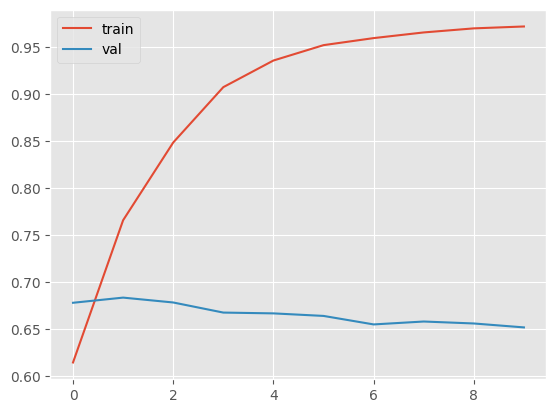

In [64]:
## Accuracy
plt.style.use("ggplot")
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.legend(["train","val"],loc='upper left')

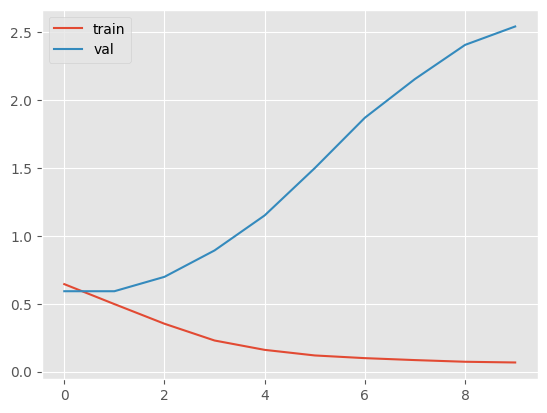

In [63]:

## Loss
plt.style.use("ggplot")
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(["train", "val"],loc='upper left')